# Modules

In [1]:
import json
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

from longitudinal_arm_swing.constants import *

pd.set_option('display.max_columns', 500)

# Constants

In [8]:
segment_lengths = ['0_20', '20_inf']
filter_type = 'filtered'
measures = ['median', '95p', 'median_cov']

path_measures = os.path.join(BASE_PATH, 'measures', f'{filter_type}_gait')
path_figures_paper = r'C:\Users\z665206\Documents\PhD\docs\papers\ppp\paper\tex\imgs'

pd_med_id_filename = 'pd_med_ids.txt'
pd_no_med_id_filename = 'pd_no_med_ids.txt'
ids_remaining_after_exclusions_filename = 'ids_remaining_after_exclusions.json'
aff_side_ids_filename = 'affected_side_ids.json'

first_week = 2
mid_week = 52
final_week = 100

off_score = 'updrs_3_hypokinesia_off_ws'
on_score = 'updrs_3_hypokinesia_on_ws'

save_plots = True

# Load

In [9]:
signal_interp_vals = {}
for group in ['pd', 'controls']:
    signal_interp_vals[group] = {}
    for segment_length in segment_lengths:
        signal_interp_vals[group][segment_length] = {}
        for measure in measures:
            signal_interp_vals[group][segment_length][measure] = pd.read_csv(os.path.join(path_measures, segment_length, f'{group}_signal_interp_{measure}_range_of_motion.csv'))

df_measures_inclusion = pd.read_parquet(os.path.join(BASE_PATH, 'measures', 'digital_measures.parquet'))

with open(os.path.join(path_measures, '20_inf', 'pd_med_ids.txt'), 'r') as f:
    pd_med_ids = f.read().splitlines()

with open(os.path.join(path_measures, '20_inf', 'pd_no_med_ids.txt'), 'r') as f:
    pd_no_med_ids = f.read().splitlines()

with open(os.path.join(PATH_IDS, ids_remaining_after_exclusions_filename), 'r') as f:
    ids_remaining_after_exclusions = json.load(f)

with open(os.path.join(PATH_IDS, aff_side_ids_filename), 'r') as f:
    aff_side_ids = json.load(f)

with open(os.path.join(PATH_IDS, 'ids_late_visit_3.txt'), 'r') as f:
    ids_late_visit3 = f.read().splitlines()

df_clinical = pd.read_parquet(os.path.join(PATH_CLINICAL_DATA, 'clinical_data.parquet'))

with open(os.path.join(path_measures, 'delta_scores.json'), 'r') as f:
    delta_scores_n_weights = json.load(f)

# Prepare data

### Clinical data

In [10]:
delta_scores = {
    'mas': {},
    'las': {},
}

regr_ids = ids_remaining_after_exclusions['ppp']['regr'] + ids_remaining_after_exclusions['denovo']['regr']

for j, subject in enumerate(regr_ids):
    if subject in aff_side_ids['ppp']['mas'] + aff_side_ids['denovo']['mas']:
        side = 'mas'
    else:
        side = 'las'

    if subject in pd_med_ids:
        med_state = 'med'
    else:
        med_state = 'no_med'

    group = f'pd_{side}'
    
    df_subject_clinical = df_clinical.loc[df_clinical['id']==subject]
    delta_scores[side][subject] = {}
    visits = df_subject_clinical['visit'].unique()

    if subject not in delta_scores_n_weights['0_20'][f'{group}_{med_state}'][measure][f'dynamic_{final_week}']['ids']:
        del delta_scores[side][subject]
        continue

    for segment_length in segment_lengths:
        delta_scores[side][subject][segment_length] = {}
        for measure in measures:
            df_subject_digital = signal_interp_vals['pd'][segment_length][measure].iloc[pd_med_ids.index(subject)]

            delta_scores[side][subject][segment_length][f'{measure}_12'] = df_subject_digital[f'week{mid_week}'] - df_subject_digital[f'week{first_week}']
            delta_scores[side][subject][segment_length][f'{measure}_13'] = df_subject_digital[f'week{final_week}'] - df_subject_digital[f'week{first_week}']
            delta_scores[side][subject][segment_length][f'{measure}_23'] = df_subject_digital[f'week{final_week}'] - df_subject_digital[f'week{mid_week}']

            delta_scores_n_weights_focus = delta_scores_n_weights['0_20'][f'{group}_{med_state}'][measure][f'dynamic_{final_week}']

            subject_idx = delta_scores_n_weights_focus['ids'].index(subject)
            unweighted_vals = delta_scores_n_weights_focus['unweighted'][subject_idx]
            weighted_vals = delta_scores_n_weights_focus['unweighted'][subject_idx] * delta_scores_n_weights_focus['weights'][subject_idx]

            delta_scores[side][subject][segment_length][f'{measure}_13_weighted'] = weighted_vals

    if 1 in visits:
        ledd_1 = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'ledd'].values[0]
        delta_scores[side][subject]['ledd_1'] = ledd_1

        delta_scores[side][subject]['years_since_diagnosis'] = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'YearsSinceDiagFloat'].values[0]
        delta_scores[side][subject]['at_least_slight_dyskinesia_visit_1'] = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'at_least_slight_dyskinesia'].values[0]
        delta_scores[side][subject]['daily_off_state_hrs_visit_1'] = df_subject_clinical.loc[df_subject_clinical['visit']==1, 'MotComDailyOffState'].values[0]

    else:
        delta_scores[side][subject]['ledd_1'] = np.nan

    if 2 in visits:
        ledd_2 = df_subject_clinical.loc[df_subject_clinical['visit']==2, 'ledd'].values[0]
        delta_scores[side][subject]['ledd_2'] = ledd_2
        delta_scores[side][subject]['at_least_slight_dyskinesia_visit_2'] = df_subject_clinical.loc[df_subject_clinical['visit']==2, 'at_least_slight_dyskinesia'].values[0]
        delta_scores[side][subject]['daily_off_state_hrs_visit_2'] = df_subject_clinical.loc[df_subject_clinical['visit']==2, 'MotComDailyOffState'].values[0]
    else:
        delta_scores[side][subject]['ledd_2'] = np.nan

    if 3 in visits:
        ledd_3 = df_subject_clinical.loc[df_subject_clinical['visit']==3, 'ledd'].values[0]
        delta_scores[side][subject]['ledd_3'] = ledd_3
        delta_scores[side][subject]['at_least_slight_dyskinesia_visit_3'] = df_subject_clinical.loc[df_subject_clinical['visit']==3, 'at_least_slight_dyskinesia'].values[0]
        delta_scores[side][subject]['daily_off_state_hrs_visit_3'] = df_subject_clinical.loc[df_subject_clinical['visit']==3, 'MotComDailyOffState'].values[0]
    else:
        delta_scores[side][subject]['ledd_3'] = np.nan

    if pd.isna(ledd_2):
        delta_scores[side][subject]['ledd_1_2'] = np.nan
    elif pd.isna(ledd_1):
        delta_scores[side][subject]['ledd_1_2'] = ledd_2
    else:
        delta_scores[side][subject]['ledd_1_2'] = ledd_2 - ledd_1

    if pd.isna(ledd_3):
        delta_scores[side][subject]['ledd_2_3'] = np.nan
    elif pd.isna(ledd_2):
        delta_scores[side][subject]['ledd_2_3'] = np.nan
    else:
        delta_scores[side][subject]['ledd_2_3'] = ledd_3 - ledd_2

    if pd.isna(ledd_3):
        delta_scores[side][subject]['ledd_1_3'] = np.nan
    elif pd.isna(ledd_1):
        delta_scores[side][subject]['ledd_1_3'] = ledd_3
    else:
        delta_scores[side][subject]['ledd_1_3'] = ledd_3 - ledd_1

    for score in [off_score, on_score, 'updrs_2_total']:
        if all([x in visits for x in [1, 2]]):
            delta_updrs_12 = df_subject_clinical.loc[df_subject_clinical['visit']==2, score].values[0] - df_subject_clinical.loc[df_subject_clinical['visit']==1, score].values[0]
        else:
            delta_updrs_12 = np.nan

        if all([x in visits for x in [1, 3]]):
            delta_updrs_13 = df_subject_clinical.loc[df_subject_clinical['visit']==3, score].values[0] - df_subject_clinical.loc[df_subject_clinical['visit']==1, score].values[0]
        else:
            delta_updrs_13 = np.nan
        
        if all([x in visits for x in [2, 3]]):
            delta_updrs_23 = df_subject_clinical.loc[df_subject_clinical['visit']==3, score].values[0] - df_subject_clinical.loc[df_subject_clinical['visit']==2, score].values[0]
        else:
            delta_updrs_23 = np.nan

        delta_scores[side][subject][f'{score}_12'] = delta_updrs_12
        delta_scores[side][subject][f'{score}_13'] = delta_updrs_13
        delta_scores[side][subject][f'{score}_23'] = delta_updrs_23


# Regression

In [11]:
measure = 'median_cov'
segment_length = 'short'

dfs = []
for side in ['mas', 'las']:
    ledd_ids = list(delta_scores[side].keys())

    dfs.append(pd.DataFrame({
        'id': ledd_ids,
        'most_affected_side': [1 if x in delta_scores['mas'] else 0 for x in ledd_ids],
        # 'ledd_baseline': [delta_scores[side][x]['ledd_1'] for x in ledd_ids],
        'delta_ledd': [delta_scores[side][x]['ledd_1_3'] for x in ledd_ids],
        'delta_median_short': [delta_scores[side][x]['0_20']['median_13'] for x in ledd_ids],
        'delta_median_long': [delta_scores[side][x]['20_inf']['median_13'] for x in ledd_ids],
        'delta_95p_short': [delta_scores[side][x]['0_20']['95p_13'] for x in ledd_ids],
        'delta_95p_long': [delta_scores[side][x]['20_inf']['95p_13'] for x in ledd_ids],
        'delta_median_cov_short': [delta_scores[side][x]['0_20']['median_cov_13'] for x in ledd_ids],
        'delta_median_cov_long': [delta_scores[side][x]['20_inf']['median_cov_13'] for x in ledd_ids],
        'years_since_diagnosis': [delta_scores[side][x]['years_since_diagnosis'] for x in ledd_ids],
        # 'dyskinesia_baseline': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
        'delta_dyskinesia': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_3'].astype(int) - 
                             delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
    }))

df_ols = pd.concat(dfs)

target_column = f'delta_{measure}_{segment_length}'
covariates = ['most_affected_side', 'delta_ledd', 'years_since_diagnosis', 'delta_dyskinesia'] # 

interaction_covs = []
for cov in covariates:
    if cov != "most_affected_side" and 'baseline' not in cov:
        interaction_cov =f"{cov}_x_most_affected_side"
        df_ols[interaction_cov] = df_ols[cov] * df_ols["most_affected_side"]
        interaction_covs.append(interaction_cov)

nonbinary_covariates = ['delta_ledd', 'years_since_diagnosis', 'delta_dyskinesia']

df_ols_regr = df_ols.dropna(subset=[target_column] + covariates)

y = df_ols_regr[target_column]
X = df_ols_regr[covariates + interaction_covs]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     delta_median_cov_short   R-squared:                       0.107
Model:                                OLS   Adj. R-squared:                  0.084
Method:                     Least Squares   F-statistic:                     4.587
Date:                    Tue, 09 Sep 2025   Prob (F-statistic):           7.37e-05
Time:                            08:45:34   Log-Likelihood:                 561.01
No. Observations:                     275   AIC:                            -1106.
Df Residuals:                         267   BIC:                            -1077.
Df Model:                               7                                         
Covariance Type:                nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [12]:
# standardize = True
# save_plot = False

# df_ols_std = df_ols.copy()
# df_ols_std = df_ols_std.dropna(subset=['delta_ledd'])

# if standardize:
#     xlabel = 'Standardized $\\beta$ coefficient (95% CI)'
#     scaler = StandardScaler()
#     df_ols_std[nonbinary_covariates] = scaler.fit_transform(df_ols_std[nonbinary_covariates])
# else:
#     xlabel = 'Coefficients'

# map_covariates = {
#     # 'most_affected_side': 'Most affected side',
#     'years_since_diagnosis': 'Years since diagnosis',
#     'delta_ledd': 'Change in LEDD',
#     'delta_dyskinesia': 'Change in dyskinesia',
# }

# fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(11, len(measures) * 4), sharex=False, sharey=True)

# for i, measure in enumerate(measures):
#     for j, segment_length in enumerate(['short', 'long']):
#         print(f'\n{measure.capitalize()} RoM, {segment_length.capitalize()} gait segments')
#         y = df_ols_std[f'delta_{measure}_{segment_length}']
#         X = df_ols_std[covariates]
#         X = sm.add_constant(X) 

#         model = sm.OLS(y, X).fit()

#         fp_list = []
#         for m, covariate in enumerate(X.columns):
#             fp_list.append([covariate, model.params[m], model.conf_int()[0].values[m], model.conf_int()[1].values[m], model.pvalues[m]])

#         df_ols_plot = pd.DataFrame(fp_list, columns=['covariate', 'coefficient', 'ci_lower', 'ci_upper', 'pvalue'])
#         df_ols_plot = df_ols_plot.loc[df_ols_plot['covariate'] != 'const'].reset_index(drop=True)

#         df_ols_plot = df_ols_plot[df_ols_plot['covariate'].isin(map_covariates.keys())].copy()
#         df_ols_plot['covariate_renamed'] = df_ols_plot['covariate'].map(map_covariates)

#         df_ols_plot['sort_order'] = df_ols_plot['covariate'].apply(lambda x: list(map_covariates.keys()).index(x))
#         df_ols_plot = df_ols_plot.sort_values('sort_order', ascending=False).reset_index(drop=True)

#         df = df_ols_plot.reset_index(drop=True)

#         df['y_pos'] = range(len(df))

#         # Loop through each row to plot colored bars and error bars
#         for _, row in df.iterrows():
#             ax[i,j].errorbar(
#                 x=row['coefficient'],
#                 y=row['y_pos'],
#                 xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]],
#                 fmt='D',
#                 color='black',
#                 markersize=6,
#                 zorder=3
#             )

#             ax[i,j].text(
#                 row['coefficient'],
#                 row['y_pos'] + 0.25,
#                 f"{row['coefficient']:.2f}",
#                 va='center',
#                 ha='center',
#                 fontsize=PLOT_TEXTSIZE,
#                 color='black',
#                 weight='bold',
#                 clip_on=True,
#                 zorder=2
#             )

#             print(f"{row['covariate_renamed']}: {row['coefficient']:.{decimals}f} ({row['ci_lower']:.{decimals}f}, {row['ci_upper']:.{decimals}f}), p={row['pvalue']:.3f}")

#         if i != 2:
#             ax[i, j].set_xlim([-1.5, 11])   
#         else:
#             ax[i, j].set_xlim([-1.5, 5])

#         ax[i, j].set_ylim([-0.5, len(df) - 0.5])

#         if j == 0:
#             ax[i, j].set_ylabel(f'{AGGREGATION_RENAMING[measure]} RoM', fontsize=PLOT_TITLESIZE)
#             ax[i, j].tick_params(axis='y', left=False, labelleft=False)
#         else:
#             ax[i, j].set_yticks(df['y_pos'])
#             ax[i, j].set_yticklabels(df['covariate_renamed'], fontsize=PLOT_TICKSIZE)
#             ax[i, j].tick_params(axis='y', labelright=True, right=True)
#             ax[i, j].yaxis.set_label_position("right")
            
#         if i == 0:
#             ax[i, j].set_title(f'{segment_length.capitalize()} gait segments', fontsize=PLOT_TITLESIZE)
#         elif i == 2:
#             ax[i, j].set_xlabel(xlabel, fontsize=PLOT_LABELSIZE)

#         ax[i, j].tick_params(axis='x', labelsize=PLOT_TICKSIZE)

#         ax[i, j].axvline(x=0, linestyle='--', color='black', alpha=0.3, linewidth=1)

# plt.tight_layout()
# plt.show()

# if save_plot:
#     fig.savefig(os.path.join(path_figures_paper, 'r_regr.png'), bbox_inches='tight', dpi=300)


median - short - delta_ledd MAS: 0.20 (0.06, 0.33), p=0.005
median - short - delta_ledd LAS: 0.09 (-0.10, 0.28), p=0.339
median - short - delta_dyskinesia MAS: 0.15 (0.01, 0.29), p=0.036
median - short - delta_dyskinesia LAS: -0.04 (-0.22, 0.14), p=0.662
median - long - delta_ledd MAS: 0.09 (-0.05, 0.24), p=0.219
median - long - delta_ledd LAS: 0.06 (-0.14, 0.26), p=0.564
median - long - delta_dyskinesia MAS: 0.09 (-0.06, 0.24), p=0.237
median - long - delta_dyskinesia LAS: 0.11 (-0.09, 0.30), p=0.272
95p - short - delta_ledd MAS: 0.15 (0.01, 0.29), p=0.033
95p - short - delta_ledd LAS: 0.05 (-0.14, 0.25), p=0.576
95p - short - delta_dyskinesia MAS: 0.20 (0.06, 0.34), p=0.006
95p - short - delta_dyskinesia LAS: 0.02 (-0.16, 0.21), p=0.816
95p - long - delta_ledd MAS: 0.16 (0.02, 0.30), p=0.024
95p - long - delta_ledd LAS: 0.19 (-0.01, 0.38), p=0.057
95p - long - delta_dyskinesia MAS: 0.16 (0.01, 0.30), p=0.031
95p - long - delta_dyskinesia LAS: 0.16 (-0.02, 0.35), p=0.085
median_cov - 

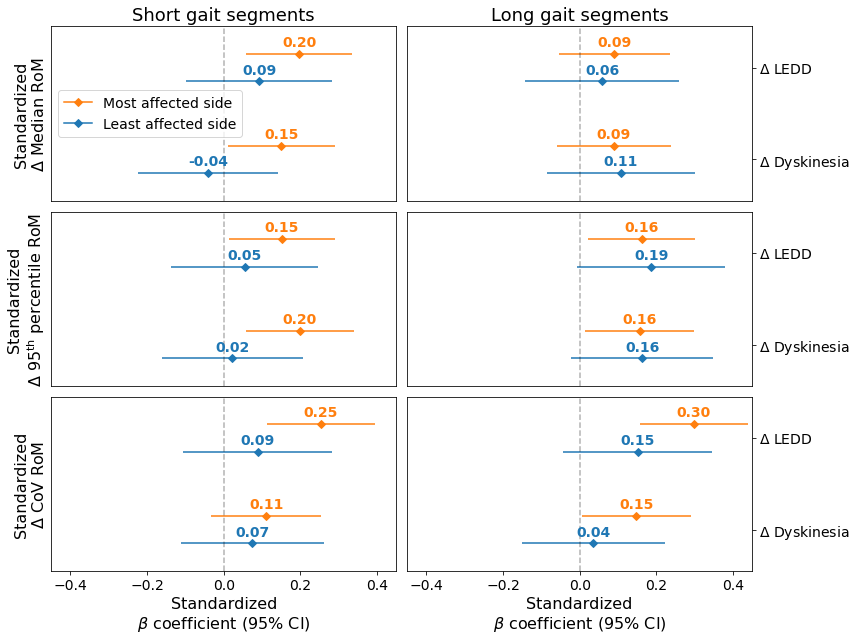

In [13]:
standardize = True

dfs = []
for side in ['mas', 'las']:
    ledd_ids = list(delta_scores[side].keys())

    dfs.append(pd.DataFrame({
        'id': ledd_ids,
        'most_affected_side': [1 if x in delta_scores['mas'] else 0 for x in ledd_ids],
        'delta_ledd': [delta_scores[side][x]['ledd_1_3'] for x in ledd_ids],
        'delta_median_short': [delta_scores[side][x]['0_20']['median_13'] for x in ledd_ids],
        'delta_median_long': [delta_scores[side][x]['20_inf']['median_13'] for x in ledd_ids],
        'delta_95p_short': [delta_scores[side][x]['0_20']['95p_13'] for x in ledd_ids],
        'delta_95p_long': [delta_scores[side][x]['20_inf']['95p_13'] for x in ledd_ids],
        'delta_median_cov_short': [delta_scores[side][x]['0_20']['median_cov_13'] * 100 for x in ledd_ids],
        'delta_median_cov_long': [delta_scores[side][x]['20_inf']['median_cov_13'] * 100 for x in ledd_ids],
        'years_since_diagnosis': [delta_scores[side][x]['years_since_diagnosis'] for x in ledd_ids],
        'delta_dyskinesia': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_3'].astype(int) - 
                             delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
    }))

df_ols = pd.concat(dfs)

covariates = ['most_affected_side', 'years_since_diagnosis', 'delta_ledd', 'delta_dyskinesia']
covariates_interaction = ['delta_ledd', 'delta_dyskinesia']

# mark which ones to standardize
nonbinary_covariates = ['delta_ledd', 'years_since_diagnosis', 'delta_dyskinesia',
                        'delta_median_short', 'delta_median_long', 'delta_95p_short',
                        'delta_95p_long', 'delta_median_cov_short', 'delta_median_cov_long']

df_ols = df_ols.dropna(subset=['delta_ledd'])

if standardize:
    xlabel = 'Standardized\n$\\beta$ coefficient (95% CI)'
    scaler = StandardScaler()
    df_ols[nonbinary_covariates] = scaler.fit_transform(df_ols[nonbinary_covariates])
else:
    xlabel = '$\\beta$ coefficient (95% CI)'

for cov in covariates_interaction:
    df_ols[f"{cov}_x_most_affected_side"] = df_ols[cov] * df_ols["most_affected_side"]

map_covariates = {
    # 'most_affected_side': 'Most affected side',
    'years_since_diagnosis': 'Years since diagnosis',
    'delta_ledd': '$\Delta$ LEDD',
    'delta_dyskinesia': '$\Delta$ Dyskinesia',
    'years_since_diagnosis_x_most_affected_side': 'Years since diagnosis × Most affected side',
    'delta_ledd_x_most_affected_side': 'LEDD × Most affected side',
    'delta_dyskinesia_x_most_affected_side': 'Dyskinesia × Most affected side',
}

plot_covs = ['delta_ledd', 'delta_dyskinesia']

plot_rows = []
all_models = {}
for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        y = df_ols[f'delta_{measure}_{segment_length}']

        X = df_ols[covariates + [f"{cov}_x_most_affected_side" for cov in covariates_interaction]]
        X = sm.add_constant(X)

        model = sm.OLS(y, X).fit()

        ci = model.conf_int().to_dict()
        conf_int = {
            param: (np.round(ci[0][param], 2), np.round(ci[1][param], 2))
            for param in model.params.index
        }

        all_models[f'{measure}_{segment_length}'] = {
            "measure": measure,
            "segment_length": segment_length,
            "params": {x: np.round(y, 2) for x, y in model.params.to_dict().items()},
            "conf_int": conf_int,
            "pvalues": {x: np.round(y, 5) for x, y in model.pvalues.to_dict().items()},
            "rsquared": np.round(model.rsquared, 4),
            "nobs": model.nobs,
        }

        for cov in plot_covs:
            # Least affected side (reference)
            coef_las = model.params[cov]
            ci_las = model.conf_int().loc[cov].values
            pval_las = model.pvalues[cov]

            plot_rows.append({
                'measure': measure,
                'segment_length': segment_length,
                'covariate': cov,
                'side': 'las',
                'coefficient': coef_las,
                'ci_lower': ci_las[0],
                'ci_upper': ci_las[1],
            })

            # Most-affected side (combined slope)
            # Use t_test to get correct SE and CI
            contrast = f"{cov} + {cov}_x_most_affected_side = 0"
            ttest_mas = model.t_test(contrast)
            coef_mas = ttest_mas.effect[0]
            ci_mas = ttest_mas.conf_int()[0]
            
            plot_rows.append({
                'measure': measure,
                'segment_length': segment_length,
                'covariate': cov,
                'side': 'mas',
                'coefficient': coef_mas,
                'ci_lower': ci_mas[0],
                'ci_upper': ci_mas[1],
            })

            print(f"{measure} - {segment_length} - {cov} MAS: {coef_mas:.{2}f} ({ci_mas[0]:.{2}f}, {ci_mas[1]:.{2}f}), p={ttest_mas.pvalue:.3f}")
            print(f"{measure} - {segment_length} - {cov} LAS: {coef_las:.{2}f} ({ci_las[0]:.{2}f}, {ci_las[1]:.{2}f}), p={pval_las:.3f}")

df_plot = pd.DataFrame(plot_rows)
df_plot['covariate_renamed'] = df_plot['covariate'].map(map_covariates)

fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(12, len(measures)*3), sharex=False, sharey=False)

x_ratios = {}
for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        df_sub = df_plot[(df_plot['measure'] == measure) & (df_plot['segment_length'] == segment_length)].copy()

        cov_to_y = {cov: i for i, cov in enumerate(reversed(plot_covs))}
        df_sub['y_pos'] = df_sub['covariate'].map(cov_to_y)
        
        y_offsets = {'mas': 0.15, 'las': -0.15}
        df_sub['y_pos_offset'] = df_sub.apply(lambda row: row['y_pos'] + y_offsets[row['side']], axis=1)
        
        for _, row in df_sub.iterrows():
            y = row['y_pos'] + y_offsets[row['side']]
            color = 'tab:orange' if row['side'] == 'mas' else 'tab:blue'
            
            ax[i, j].errorbar(
                x=row['coefficient'],
                y=row['y_pos_offset'],
                xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]],
                fmt='D',
                color=color,
                markersize=6,
                label=row['side']
            )
            if np.abs(row['coefficient']) < 0.01:
                notation = f"{row['coefficient']:.2e}"
            else:
                notation = f"{row['coefficient']:.2f}"
            ax[i, j].text(
                row['coefficient'],
                y + 0.05,
                notation,
                ha='center', va='bottom', fontsize=PLOT_TEXTSIZE, color=color, weight='bold',
            )
        
        if j == 0:
            ylabel = f'Standardized\n$\Delta$ {AGGREGATION_RENAMING[measure]} RoM'
            ax[i, j].set_ylabel(ylabel, fontsize=PLOT_LABELSIZE)
            ax[i, j].tick_params(axis='y', left=False, labelleft=False)
        else:
            ax[i, j].tick_params(axis='y', left=False, labelleft=False, labelright=True, right=True)
            ax[i, j].yaxis.set_label_position("right")
            ax[i, j].set_yticks(range(len(plot_covs)))
            ax[i, j].set_yticklabels([map_covariates[cov] for cov in cov_to_y.keys()], fontsize=PLOT_TICKSIZE)

        y_min = df_sub['y_pos_offset'].min() - 0.3  
        y_max = df_sub['y_pos_offset'].max() + 0.3  
        
        ax[i, j].set_ylim([y_min, y_max])
        ax[i, j].tick_params(axis='x', labelsize=PLOT_TICKSIZE)
        ax[i, j].axvline(x=0, color='black', linestyle='--', alpha=0.3)

        if i == 0:
            ax[i, j].set_title(f"{segment_length.capitalize()} gait segments", fontsize=PLOT_TITLESIZE)
        elif i == len(measures) - 1:
            ax[i, j].set_xlabel(xlabel, fontsize=PLOT_LABELSIZE)
        
        if i != len(measures) - 1:
            ax[i, j].set_xticks([])

        ax[i, j].set_xlim([-0.45, 0.45])

legend_handles = [
    Line2D([0], [0], marker='D', color='tab:orange', linestyle='-', markersize=6, label='Most affected side'),
    Line2D([0], [0], marker='D', color='tab:blue', linestyle='-', markersize=6, label='Least affected side')
]

# Add legend to the first subplot (or wherever you want)
ax[0, 0].legend(handles=legend_handles, fontsize=PLOT_TICKSIZE, loc='center left', frameon=True)

plt.tight_layout()
plt.show()

if save_plots:
    fig.savefig(os.path.join(PATH_FIGURES, 'r_regr.png'), bbox_inches='tight', dpi=600)
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', 'r_regr.pdf'), bbox_inches='tight', dpi=600)

with open(os.path.join(PATH_FIGURES, 'r_regr_all_models.json'), 'w') as f:
    json.dump(all_models, f, indent=4)

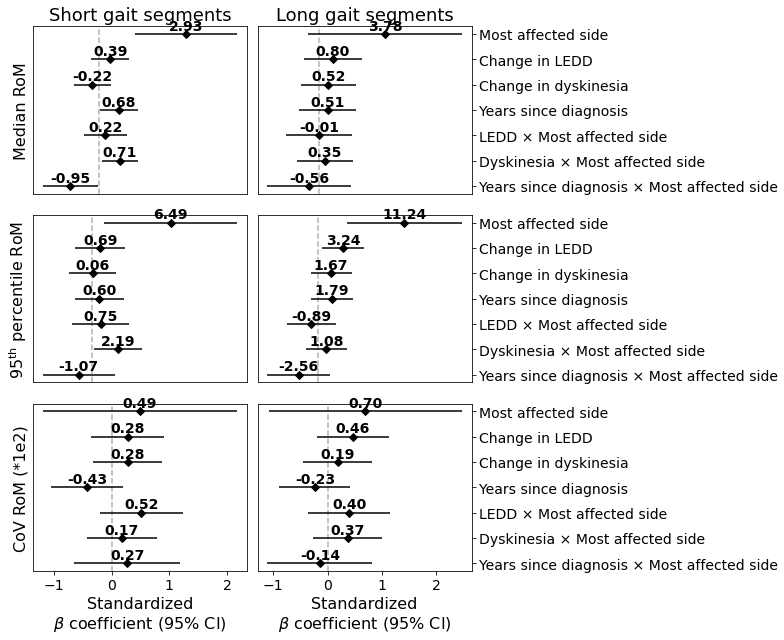

In [16]:
standardize = True

dfs = []
for side in ['mas', 'las']:
    ledd_ids = list(delta_scores[side].keys())

    dfs.append(pd.DataFrame({
        'id': ledd_ids,
        'most_affected_side': [1 if x in delta_scores['mas'] else 0 for x in ledd_ids],
        'delta_ledd': [delta_scores[side][x]['ledd_1_3'] for x in ledd_ids],
        'delta_median_short': [delta_scores[side][x]['0_20']['median_13'] for x in ledd_ids],
        'delta_median_long': [delta_scores[side][x]['20_inf']['median_13'] for x in ledd_ids],
        'delta_95p_short': [delta_scores[side][x]['0_20']['95p_13'] for x in ledd_ids],
        'delta_95p_long': [delta_scores[side][x]['20_inf']['95p_13'] for x in ledd_ids],
        'delta_median_cov_short': [delta_scores[side][x]['0_20']['median_cov_13'] * 100 for x in ledd_ids],
        'delta_median_cov_long': [delta_scores[side][x]['20_inf']['median_cov_13'] * 100 for x in ledd_ids],
        'years_since_diagnosis': [delta_scores[side][x]['years_since_diagnosis'] for x in ledd_ids],
        # 'dyskinesia_baseline': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
        'delta_dyskinesia': [delta_scores[side][x]['at_least_slight_dyskinesia_visit_3'].astype(int) - 
                             delta_scores[side][x]['at_least_slight_dyskinesia_visit_1'].astype(int) for x in ledd_ids],
    }))

df_ols = pd.concat(dfs)

covariates = ['most_affected_side', 'delta_ledd', 'delta_dyskinesia', 'years_since_diagnosis']

for cov in covariates:
    if cov != "most_affected_side":
        df_ols[f"{cov}_x_most_affected_side"] = df_ols[cov] * df_ols["most_affected_side"]

# mark which ones to standardize
nonbinary_covariates = [
    'delta_ledd', 
    'years_since_diagnosis',
    'delta_dyskinesia',
    'delta_ledd_x_most_affected_side',
    'years_since_diagnosis_x_most_affected_side',
    'delta_dyskinesia_x_most_affected_side'
]

df_ols_std = df_ols.copy()
df_ols_std = df_ols_std.dropna(subset=['delta_ledd'])

if standardize:
    xlabel = 'Standardized\n$\\beta$ coefficient (95% CI)'
    scaler = StandardScaler()
    df_ols_std[nonbinary_covariates] = scaler.fit_transform(df_ols_std[nonbinary_covariates])
else:
    xlabel = '$\\beta$ coefficient (95% CI)'

map_covariates = {
    'most_affected_side': 'Most affected side',
    'years_since_diagnosis': 'Years since diagnosis',
    'delta_ledd': 'Change in LEDD',
    'delta_dyskinesia': 'Change in dyskinesia',
    'years_since_diagnosis_x_most_affected_side': 'Years since diagnosis × Most affected side',
    'delta_ledd_x_most_affected_side': 'LEDD × Most affected side',
    'delta_dyskinesia_x_most_affected_side': 'Dyskinesia × Most affected side',
}

plot_covs = ['delta_ledd', 'delta_dyskinesia']
all_covs = covariates + [f"{cov}_x_most_affected_side" for cov in covariates if cov != "most_affected_side"]

plot_rows = []
for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        y = df_ols_std[f'delta_{measure}_{segment_length}']

        X = df_ols_std[all_covs]
        X = sm.add_constant(X) 

        model = sm.OLS(y, X).fit()

        for cov in all_covs:
            coef = model.params[cov]
            ci = model.conf_int().loc[cov].values
            plot_rows.append({
                'measure': measure,
                'segment_length': segment_length,
                'covariate': cov,
                'coefficient': coef,
                'ci_lower': ci[0],
                'ci_upper': ci[1],
            })

df_plot = pd.DataFrame(plot_rows)
df_plot['covariate_renamed'] = df_plot['covariate'].map(map_covariates)

fig, ax = plt.subplots(nrows=len(measures), ncols=2, figsize=(11, len(measures)*3), sharex=False, sharey=False)

x_ratios = {}
for i, measure in enumerate(measures):
    for j, segment_length in enumerate(['short', 'long']):
        df_sub = df_plot[(df_plot['measure'] == measure) & (df_plot['segment_length'] == segment_length)].copy()

        cov_to_y = {cov: i for i, cov in enumerate(reversed(all_covs))}
        df_sub['y_pos'] = df_sub['covariate'].map(cov_to_y)
        
        # y_offsets = {'mas': 0.15, 'las': -0.15}
        # df_sub['y_pos_offset'] = df_sub.apply(lambda row: row['y_pos'] + y_offsets[row['side']], axis=1)
        
        for _, row in df_sub.iterrows():
            # y = row['y_pos'] + y_offsets[row['side']]
            # color = 'tab:orange' if row['side'] == 'mas' else 'tab:blue'
            
            ax[i, j].errorbar(
                x=row['coefficient'],
                y=row['y_pos'],
                xerr=[[row['coefficient'] - row['ci_lower']], [row['ci_upper'] - row['coefficient']]],
                fmt='D',
                color='black',
                markersize=6,
            )
            ax[i, j].text(
                row['coefficient'],
                row['y_pos'] + 0.05,
                f"{row['coefficient']:.2f}",
                ha='center', va='bottom', fontsize=PLOT_TEXTSIZE, color='black', weight='bold',
            )
        
        if j == 0:
            if measure == 'median_cov':
                ylabel = f'{AGGREGATION_RENAMING[measure]} RoM (*1e2)'
            else:
                ylabel = f'{AGGREGATION_RENAMING[measure]} RoM'
            ax[i, j].set_ylabel(ylabel, fontsize=PLOT_LABELSIZE)
            ax[i, j].tick_params(axis='y', left=False, labelleft=False)
        else:
            ax[i, j].tick_params(axis='y', left=False, labelleft=False, labelright=True, right=True)
            ax[i, j].yaxis.set_label_position("right")
            ax[i, j].set_yticks(range(len(all_covs)))
            ax[i, j].set_yticklabels([map_covariates[cov] for cov in cov_to_y.keys()], fontsize=PLOT_TICKSIZE)

        ax[i, j].tick_params(axis='x', labelsize=PLOT_TICKSIZE)
        ax[i, j].axvline(x=0, color='black', linestyle='--', alpha=0.3)

        if i == 0:
            ax[i, j].set_title(f"{segment_length.capitalize()} gait segments", fontsize=PLOT_TITLESIZE)
        elif i == len(measures) - 1:
            ax[i, j].set_xlabel(xlabel, fontsize=PLOT_LABELSIZE)
        
        if i != len(measures) - 1:
            ax[i, j].set_xticks([])

        # ax[i, j].set_xlim([-2.1, 6.5])

plt.tight_layout()
plt.show()